# **Recommendation Engine Model**

This model recommends product categories to customers based on their
spending behavior.

It uses Cosine Similarity to identify customers with similar purchase
patterns and suggests products preferred by similar customers.


## Problem Statement

Customers spend different amounts on different product categories.

The goal of this model is to:
- Identify customers with similar spending patterns.
- Recommend product categories based on similar customers' preferences.

This improves personalization and increases business revenue.


## Algorithm Used: Cosine Similarity

Cosine Similarity measures similarity between two customers by calculating
the cosine of the angle between their spending vectors.

Customers with higher cosine similarity values are considered more similar.


In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity


## Load Dataset

The marketing_campaign dataset is tab-separated.
Therefore, we load it using sep="\t".


In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")

# Remove unwanted spaces from column names
df.columns = df.columns.str.strip()

df.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


## Dataset Information


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

## Feature Selection

We use only spending-related features for recommendations.


In [4]:
features = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

data = df[features]


## Handling Missing Values

We replace missing values with 0.


In [5]:
data = data.fillna(0)


## Data Normalization

Normalization ensures all spending features contribute equally
to similarity calculation.


In [6]:
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


## Cosine Similarity Calculation

We compute similarity between customers based on spending patterns.


In [7]:
similarity_matrix = cosine_similarity(data_scaled)


## Recommendation Function

This function finds customers most similar to a given customer
and recommends products they spend the most on.


In [8]:
def recommend_products(customer_id, top_n=3):

    similarity_scores = list(enumerate(similarity_matrix[customer_id]))

    similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)

    similar_customers = [i[0] for i in similarity_scores[1:top_n+1]]

    avg_spending = df.loc[similar_customers, features].mean()

    recommended_products = avg_spending.sort_values(ascending=False)

    return recommended_products


## Test Recommendation


In [9]:
customer_id = 0

recommendations = recommend_products(customer_id)

print("Recommended product categories for customer", customer_id)
print(recommendations)


Recommended product categories for customer 0
MntWines            874.666667
MntMeatProducts     583.000000
MntFishProducts     235.666667
MntFruits           118.666667
MntSweetProducts    116.333333
MntGoldProds        104.666667
dtype: float64


## Output

The output ranks product categories based on average spending
of similar customers.

Top-ranked products are recommended to the target customer.


In [14]:
import pickle


In [15]:
# Save scaler
with open("recommendation_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# Save similarity matrix
with open("similarity_matrix.pkl", "wb") as f:
    pickle.dump(similarity_matrix, f)

# Save feature list
with open("recommendation_features.pkl", "wb") as f:
    pickle.dump(features, f)

print("All model files saved successfully ✅")


All model files saved successfully ✅


## Save Model Files

We save:
- Scaler
- Similarity Matrix
- Feature List

These files will be used in the backend system.


## Recommendation Visualization

This graph shows the recommended product categories ranked by average spending
of similar customers.

Higher bars indicate stronger recommendation.


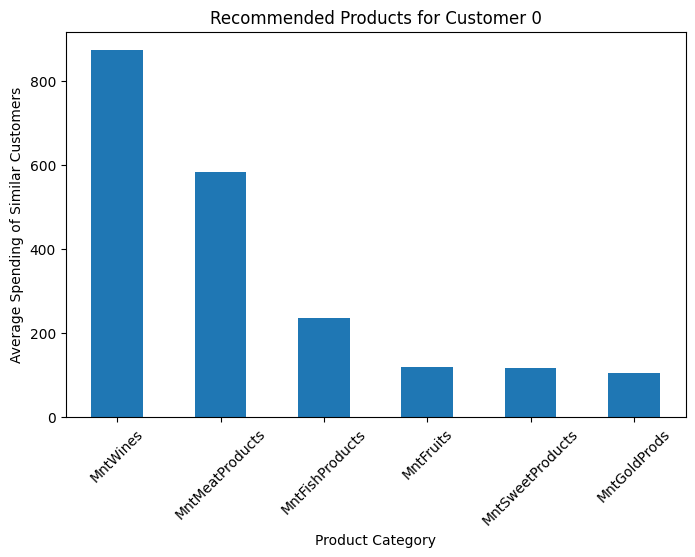

In [12]:
import matplotlib.pyplot as plt

customer_id = 0
recommendations = recommend_products(customer_id)

# Plot only top 6 recommendations
plt.figure(figsize=(8,5))
recommendations.head(6).plot(kind='bar')

plt.title(f"Recommended Products for Customer {customer_id}")
plt.ylabel("Average Spending of Similar Customers")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.show()


## Similarity Heatmap

This heatmap shows similarity scores between customers.
Darker colors indicate higher similarity.


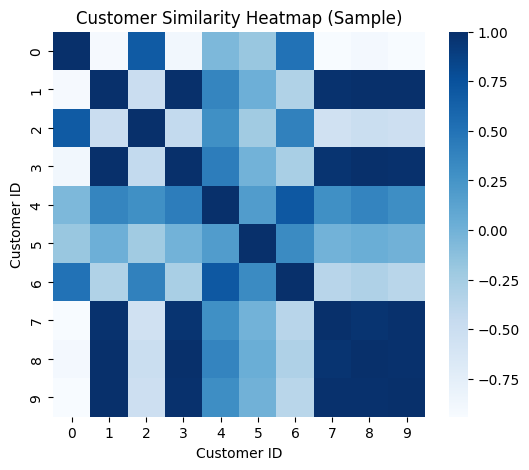

In [13]:
import seaborn as sns

# Show only first 10 customers
sample_similarity = similarity_matrix[:10, :10]

plt.figure(figsize=(6,5))
sns.heatmap(sample_similarity, cmap="Blues")

plt.title("Customer Similarity Heatmap (Sample)")
plt.xlabel("Customer ID")
plt.ylabel("Customer ID")
plt.show()
